# Phase One: EDA and Dimensionality Reduction

In [50]:
import ee


print("Authenticating with Google Earth Engine...")
ee.Authenticate()

print("Initializing project...")
ee.Initialize(project="agriculture-drought-assesment")

Authenticating with Google Earth Engine...
Initializing project...


In [51]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))

In [52]:
from IPython.display import Image, display

import importlib

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn import linear_model

from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from data import indices, load_CHIRPS, load_ERA5, load_S2, utils
from visualisation import index_plotter
from features import engineering

from pygam import LinearGAM, s

importlib.reload(indices)
importlib.reload(load_S2)
importlib.reload(load_ERA5)
importlib.reload(load_CHIRPS)
importlib.reload(utils)
importlib.reload(index_plotter)
importlib.reload(engineering)

<module 'features.engineering' from '/home/luke/projects/agriculture-analysis/src/features/engineering.py'>

# Prepare DataFrames

In [73]:
region = utils.get_region()
i_date = "2021-01-01"
f_date = "2024-12-31"

In [74]:
non_spectral_df = pd.read_csv("../data/raw/non_spectral_df.csv", index_col=0)
non_spectral_df["Timestamp"] = pd.to_datetime(non_spectral_df["Timestamp"])
spectral_df = pd.read_csv("../data/raw/spectral_df.csv", index_col=0)
spectral_df["Timestamp"] = pd.to_datetime(spectral_df["Timestamp"])
grouped_spectral_df = pd.read_csv("../data/raw/grouped_spectral_df.csv", index_col=0)
grouped_spectral_df["Timestamp"] = pd.to_datetime(grouped_spectral_df["Timestamp"])

### Growing degree days

GDDs are a heuristic used to measure heat accumulation to predict plant development rates. If the crops aren't heavily stressed by other anomalous environmental factors, the development rate from emergence to maturity depends on daily temperature. The variant we will use is:

$$GDD=\text{max}\left\{\frac{T_\text{max}+T_\text{min}}{2}-T_\text{base}, 0\right\}$$

Corn typically has 800 to 2700 GDD to crop maturity, with a recommended baseline of 10 °C.

In [75]:
def gdd(row):
    t_base = 10
    
    t_max = row["temperature_2m_max"] - 273.15
    t_min = row["temperature_2m_min"] - 273.15

    gdd = (t_max + t_min) / 2 - t_base
    return max(gdd, 0)

In [76]:
non_spectral_df["GDD"] = non_spectral_df.apply(gdd, axis=1)
non_spectral_df["GDD"].head()

0    10.006207
1     7.404952
2     7.165753
3     8.108309
4    10.420760
Name: GDD, dtype: float64

In [78]:
master_df = utils.merge_with_master(grouped_spectral_df, non_spectral_df)
master_df.head()

,Timestamp,NDVI_mean,NDVI_std,NDWI_mean,NDWI_std,NDRE_mean,NDRE_std,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2,volumetric_soil_water_layer_3,...,soil_temperature_level_1,soil_temperature_level_2,soil_temperature_level_3,soil_temperature_level_4,temperature_2m,temperature_2m_min,temperature_2m_max,surface_solar_radiation_downwards_sum,precipitation,GDD
0,2018-01-07,0.454175,0.017789,0.154850,0.001513,0.301027,0.005391,0.277943,0.320916,0.297231,...,298.093380,296.435354,293.480139,291.139993,296.411982,288.101550,305.198672,3.187154e+07,0.000000,13.500111
1,2018-03-03,0.629801,0.031419,0.310717,0.025493,0.438958,0.033150,0.275499,0.294964,0.281848,...,296.319232,295.264591,293.797097,292.708587,293.174303,284.739623,300.874879,2.653625e+07,5.928807,9.657251
2,2018-06-01,0.330054,0.013942,0.073200,0.005519,0.220654,0.008582,0.387392,0.309780,0.338261,...,283.614288,284.567219,286.777798,290.473939,281.743066,275.021431,288.422674,1.504906e+07,0.000000,0.000000
3,2018-06-06,0.289118,0.015937,-0.017437,0.002453,0.180388,0.010207,0.336953,0.310565,0.336209,...,281.924616,282.769941,285.820755,290.178382,280.752142,274.098569,288.798194,1.452415e+07,0.000000,0.000000
4,2018-06-11,0.264834,0.027659,-0.018403,0.011886,0.172670,0.016877,0.307676,0.305746,0.333914,...,282.930785,283.265651,285.249282,289.847651,281.838309,276.769477,289.060574,1.396338e+07,0.000000,0.000000


---

# Growth Stages

In the feature engineering chapters to follow, we will see that the relative growth stages of maize plays an integral role in defining the influence and interpretation of many of the environmental variables in our dataset. The challenge in an unsupervised learning problem like this is the fact that we don't have access to labels detailing the growth stages of the crop, so it takes some creativity to approximately classify where in the process our crop field is. 

Maize growth is divided into two main categories, **Vegetative (V)** and **Reproductive (R)**. The vegatative ranking is determined by the amount of visible collars on the plant. 

<img src="assets/maize_collars.jpg" width="350">

The plants grow up to a V18 or V21 stage, where-after it goed into a reproductive stage and loses its greenery. 

<img src="assets/V_n_R.jpg" width="500">


Why is this important? For the simple reason that one of our spectral indices, NDVI, is as such a measurement of the "greenery" of the maize crops. More concretely, a higher NDVI tells us that the vegatation in the area under consideration reflects more near-infrared and green light as compared to other wave-lengths, but absorbs more blue and red. The higher the NDVI, the healthier and more green is the crop. In other words, as greenery increases starting from planting season, the average NDVI graph will give us a good indication of the growth stages of the maize.


$$\text{NDVI}=\frac{\text{NIR} - \text{Red}}{\text{NIR} + \text{Red}}$$

In [79]:
jul1_doy = pd.Timestamp("2021-07-01").dayofyear

plot_df = master_df[master_df["Timestamp"] < pd.to_datetime("2026-01-01")].copy()
plot_df = plot_df.sort_values("Timestamp")
#plot_df["doy"] = plot_df["Timestamp"].dt.dayofyeaar
plot_df["doy"] = ((plot_df["Timestamp"].dt.dayofyear - jul1_doy) % 365) + 1


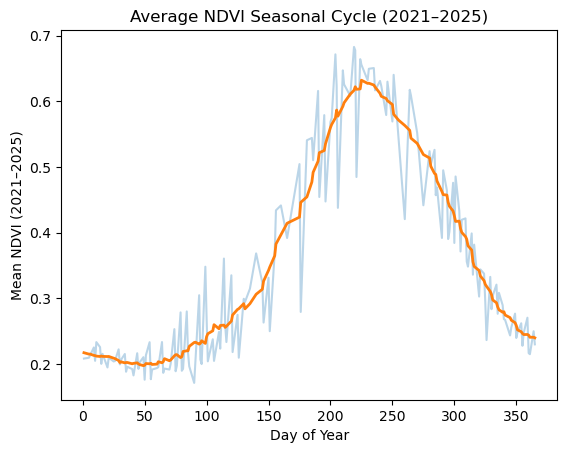

In [80]:

clim = plot_df.groupby("doy")["NDVI_mean"].mean().sort_index()
clim_smooth = clim.rolling(window=14, center=True, min_periods=1).mean()

plt.figure()
plt.plot(clim.index, clim.values, alpha=0.3, label="5-year mean")
plt.plot(clim_smooth.index, clim_smooth.values, linewidth=2, label="Smoothed")
plt.xlabel("Day of Year")
plt.ylabel("Mean NDVI (2021–2025)")
plt.title("Average NDVI Seasonal Cycle (2021–2025)")
plt.show()

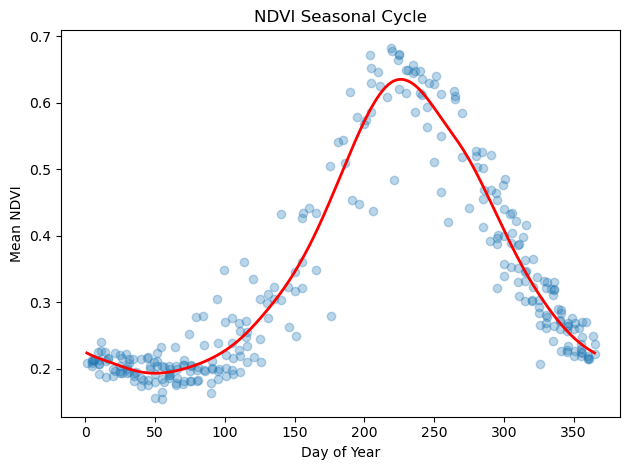

In [81]:
X = plot_df["doy"].values.reshape(-1, 1)
y = plot_df["NDVI_mean"].values

gam = LinearGAM(s(0, basis="cp")).fit(X, y)

doys = np.arange(1, 366)
pred = gam.predict(doys)

plt.figure()
plt.scatter(x = plot_df["doy"], y=plot_df["NDVI_mean"], alpha=0.3)
plt.plot(doys, pred, linewidth=2, color="red")
plt.title("NDVI Seasonal Cycle")
plt.ylabel("Mean NDVI")
plt.xlabel("Day of Year")
plt.tight_layout()
plt.show()

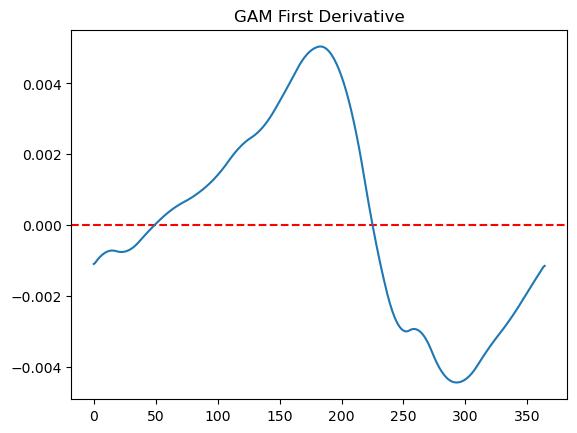

In [103]:
dy_dx = np.gradient(pred, doys)
plt.title("GAM First Derivative")
plt.axhline(y=0, color='red', linestyle='--')
plt.plot(dy_dx)

The `LinearGAM` has a first derivative representing the change in NDVI per individual day. 
- The **Start of Season** phase starts at $y>0$, i.e. the moment the maize emerges. This can be seen at around DOY 50.
- The rapid vegatitve expansioin period occurs from DOY 50 to ~180, with peak at around 180.

# Feature Engineering

## Volumetric soil water layers and soil temperature layers 

Maize crops are deep-rooted with the following cycles:
- During its vegetative stages (VE-V3), seminal roots grow mostly within 0-20cm.
- The rapid vegetative growth period (V4-V10) is when roots commonly penetrate to 40-80cm.
- Pre-tassling to flowering period (V10-VT) sees active roots extending to 1.0-1.5m
- At full maturity, the maximum root depth reaches ~1.5-2.0m (sometimes deeper).

The bulk of functional roots is not at maximum depth. It typically remains in the upper profile, i.e. 0-30cm, with depths exceeding 120cm important during _drought_ periods. 


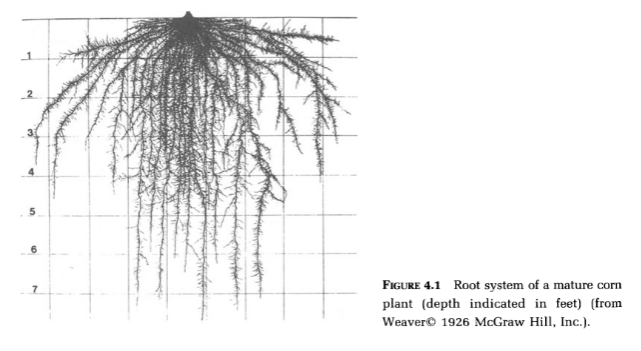

https://link.springer.com/chapter/10.1007/978-1-4612-2694-9_4 

The ERA5 dataset provides us with 4 layers of soil temperature and volumetric water layers. 


| Band Name                     | Unit            | Description                                                                                                                                                                                                                                                                                                                |   |
|-------------------------------|-----------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|---|
| soil_temperature_level_1      | K               | Temperature of the soil in layer 1 (0 - 7 cm) of the ECMWF Integrated Forecasting System. The surface is at 0 cm. Soil temperature is set at the middle of each layer, and heat transfer is calculated at the interfaces between them. It is assumed that there is no heat transfer out of the bottom of the lowest layer. |   |
| soil_temperature_level_2      | K               | Temperature of the soil in layer 2 (7-28 cm) of the ECMWF Integrated Forecasting System.                                                                                                                                                                                                                                   |   |
| soil_temperature_level_3      | K               | Temperature of the soil in layer 3 (28-100 cm) of the ECMWF Integrated Forecasting System.                                                                                                                                                                                                                                 |   |
| soil_temperature_level_4      | K               | Temperature of the soil in layer 4 (100-289 cm) of the ECMWF Integrated Forecasting System.                                                                                                                                                                                                                                |   |
| volumetric_soil_water_layer_1 | Volume fraction | Volume of water in soil layer 1 (0 - 7 cm) of the ECMWF Integrated Forecasting System. The surface is at 0 cm. The volumetric soil water is associated with the soil texture (or classification), soil depth, and the underlying groundwater level.                                                                        |   |
| volumetric_soil_water_layer_2 | Volume fraction | Volume of water in soil layer 2 (7 -28 cm) of the ECMWF Integrated Forecasting System.                                                                                                                                                                                                                                     |   |
| volumetric_soil_water_layer_3 | Volume fraction | Volume of water in soil layer 3 (28-100 cm) of the ECMWF Integrated Forecasting System.                                                                                                                                                                                                                                    |   |
| volumetric_soil_water_layer_4 | Volume fraction | Volume of water in soil layer 4 (100-289 cm) of the ECMWF Integrated Forecasting System.                                                                                                                                                                                                                                   |   |





Naturally considering these as predictors for any model introduces a significant amount of multicolinearity. One might think that dimensionality reduction would be a valid approach to address this issue, however there is a caveat - a climate shock will not have a noteworthy influence on the deep layers in a similar way that it may have on the volatile shallow levels. We must avoid a situation where these deeper layers are used mathematical anchors such  that a large change in the shallow layers will be circumvented by an insignifcant change in the deeper layers. 


### Volumetric Soil Water Layer

As stated above, the deeper layers are typically not the most important when it comes to the maize's health. This leads us to two potential paths forward:

1. **Root weighted averaging depending on growth stage**: A maize plant in its early growth stages will not have a penetrating root system at 180cm, but a mature maize plant will. We therefore introduce as features **root-zone soil moisture** ($SM_{e}$, $SM_{m}$) for both the *early* and *mature* stages of the crop:
        - $SM_{m} = $ 0-30cm has 40-50% of total water uptake, 30-100cm has 40-45% and 100-289cm has ~20%. 
        - $SM_{e} = $ 0-30cm 70-80% and 20-30% to 30-100cm

2. _Truncated_ or _Split-depth_ **Principal Component Analysis**: Instead of running one global PCA on all 4 layers, we split layers 1 and 2 from 3 and 4, and project each of these down to their first direction of maximum variance.



### Soil Temperature Layers

Soil temperatures at layers 1 and 2 are highly volatile, with swings typically mirroring the current surface weather exactly. The deeper soil temperatures are hardly effected by the diurnal temperature, meaning that the daily weather is entirely erased by the time we reach 100-289cm. Aditionally, depending on the row spacing, the maize canopy closes typically closes between the V10 and V14 vegatitve stages, which significantly reduces the diurnal fluctation at shallow levels. We will therefore follow this approach for the soil temperature:
- Drop layers 3 and 4 entirely
- Shift to air temperature and solar radiation once we reach V10-V14 vegatative stages.


In [88]:
# Define constants

VOL_SOIL = "volumetric_soil_water_layer"
SOIL_TEMP =  "soil_temperature_level"
SUB_STRINGS = {VOL_SOIL:4, SOIL_TEMP:2}

dict_items([('volumetric_soil_water_layer', 4), ('soil_temperature_level', 3)])

### Volumetric Soil Water Layers

In [79]:
scaler = StandardScaler()
pca_vw = PCA()
pca_st = PCA()
pcas = [pca_vw, pca_st]

#### Root weighted averaging

### Soil Temperature Layers

In [91]:
# Drop soil temperature layers 3 and 4

mod_non_spectral_df = non_spectral_df.drop(["soil_temperature_level_3", "soil_temperature_level_4"], axis=1)